In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ablation_results.csv')
df2 = pd.read_csv('../ablation_study/ablation_results.csv')
print(df)
print(f"\nColumns: {list(df.columns)}")
print(f"Configs: {df['Config'].unique()}")

         Dataset         Config  Accuracy       F1  Leaves  Nodes  Depth  \
0   BanknoteAuth  SR-CCP (full)   0.98742  0.98727     8.4   15.8    5.2   
1   BanknoteAuth       No Depth   0.98142  0.98127    12.6   24.2    5.8   
2   BanknoteAuth     No Feature   0.96942  0.96927    14.2   27.4    7.0   
3   BanknoteAuth   No Penalties   0.98688  0.98671    23.4   45.8    8.2   
4   BreastCancer  SR-CCP (full)   0.94377  0.93960     3.2    5.4    3.0   
5   BreastCancer       No Depth   0.92577  0.92168     7.2   13.2    4.4   
6   BreastCancer     No Feature   0.93877  0.93462     5.4    9.6    3.8   
7   BreastCancer   No Penalties   0.93149  0.92551    11.8   22.6    6.2   
8   HeartDisease  SR-CCP (full)   0.79630  0.79203     6.0   11.0    4.4   
9   HeartDisease       No Depth   0.74430  0.74031     9.8   18.4    5.4   
10  HeartDisease     No Feature   0.76430  0.76020    11.2   21.2    5.8   
11  HeartDisease   No Penalties   0.78519  0.78146    25.6   50.2    7.8   
12    Ionosp

In [15]:
# --- Summary table (Modified) ---
print('=== Modified Data ===')
summary = df.groupby('Config')[['Accuracy', 'Leaves', 'Nodes', 'Depth', 'n_Features']].mean()
print(summary.round(4))

print('\n=== Original Data ===')
summary2 = df2.groupby('Config')[['Accuracy', 'Leaves', 'Nodes', 'Depth', 'n_Features']].mean()
print(summary2.round(4))


=== Modified Data ===
               Accuracy   Leaves    Nodes   Depth  n_Features
Config                                                       
No Depth         0.8760   8.9714  16.8857  5.2286      5.5857
No Feature       0.8794  10.2000  19.3429  5.7714      6.3429
No Penalties     0.8922  28.4000  55.8000  8.9714     12.4000
SR-CCP (full)    0.8947   5.0286   9.0571  3.8571      3.2000

=== Original Data ===
               Accuracy   Leaves    Nodes   Depth  n_Features
Config                                                       
No Depth         0.8704   6.9714  12.9429  4.7429      4.6000
No Feature       0.8788  12.8571  24.7143  6.1714      6.9429
No Penalties     0.8922  28.4000  55.8000  8.9714     12.4000
SR-CCP (full)    0.8947   5.0286   9.0571  3.8571      3.2000


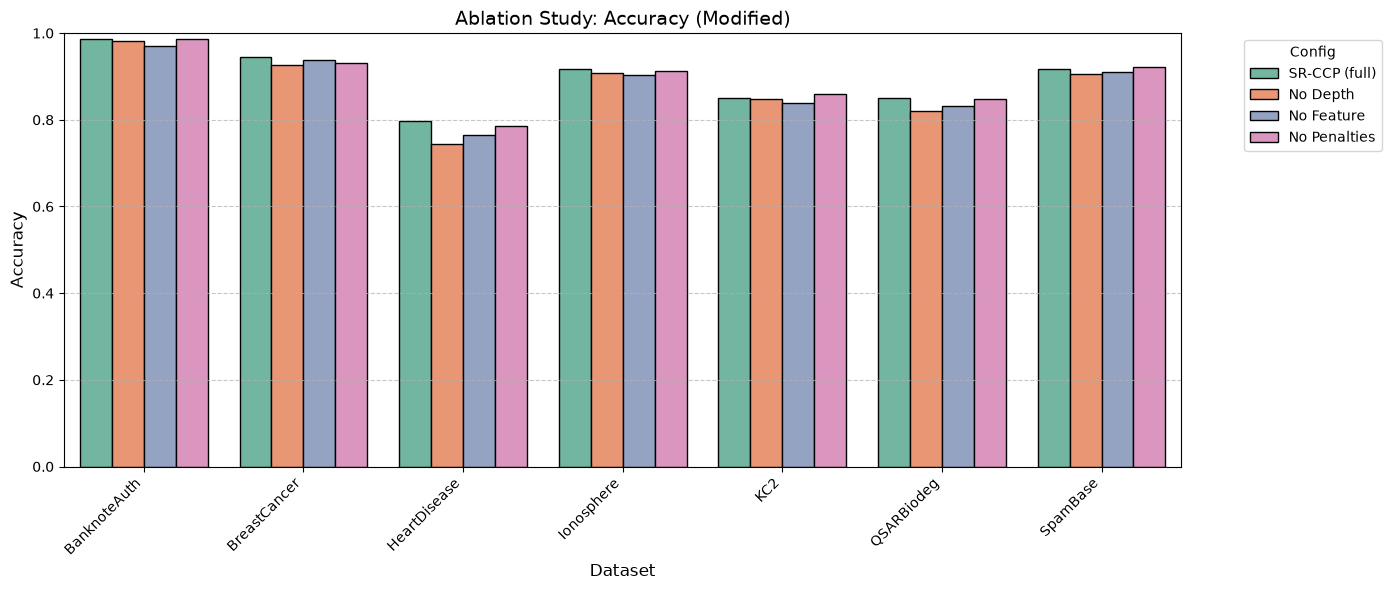

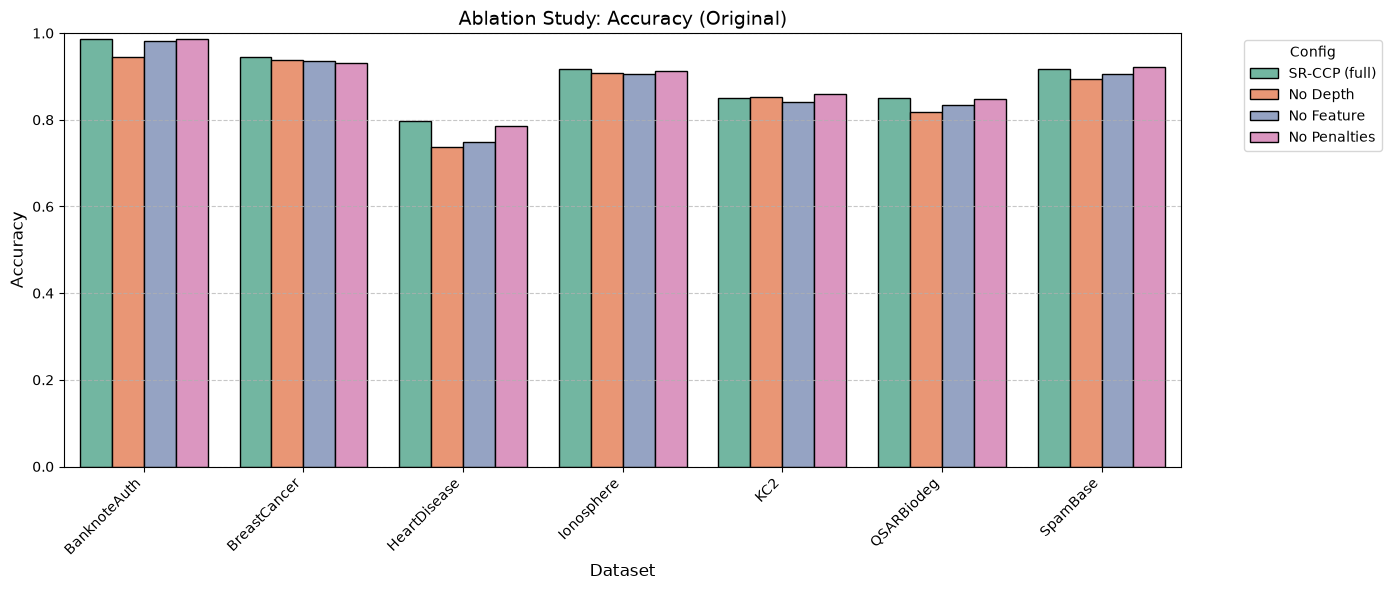

In [16]:
# --- Chart 1a: Accuracy (Modified) ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df, x='Dataset', y='Accuracy', hue='Config', palette='Set2', edgecolor='black')
plt.title('Ablation Study: Accuracy (Modified)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Chart 1b: Accuracy (Original) ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df2, x='Dataset', y='Accuracy', hue='Config', palette='Set2', edgecolor='black')
plt.title('Ablation Study: Accuracy (Original)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


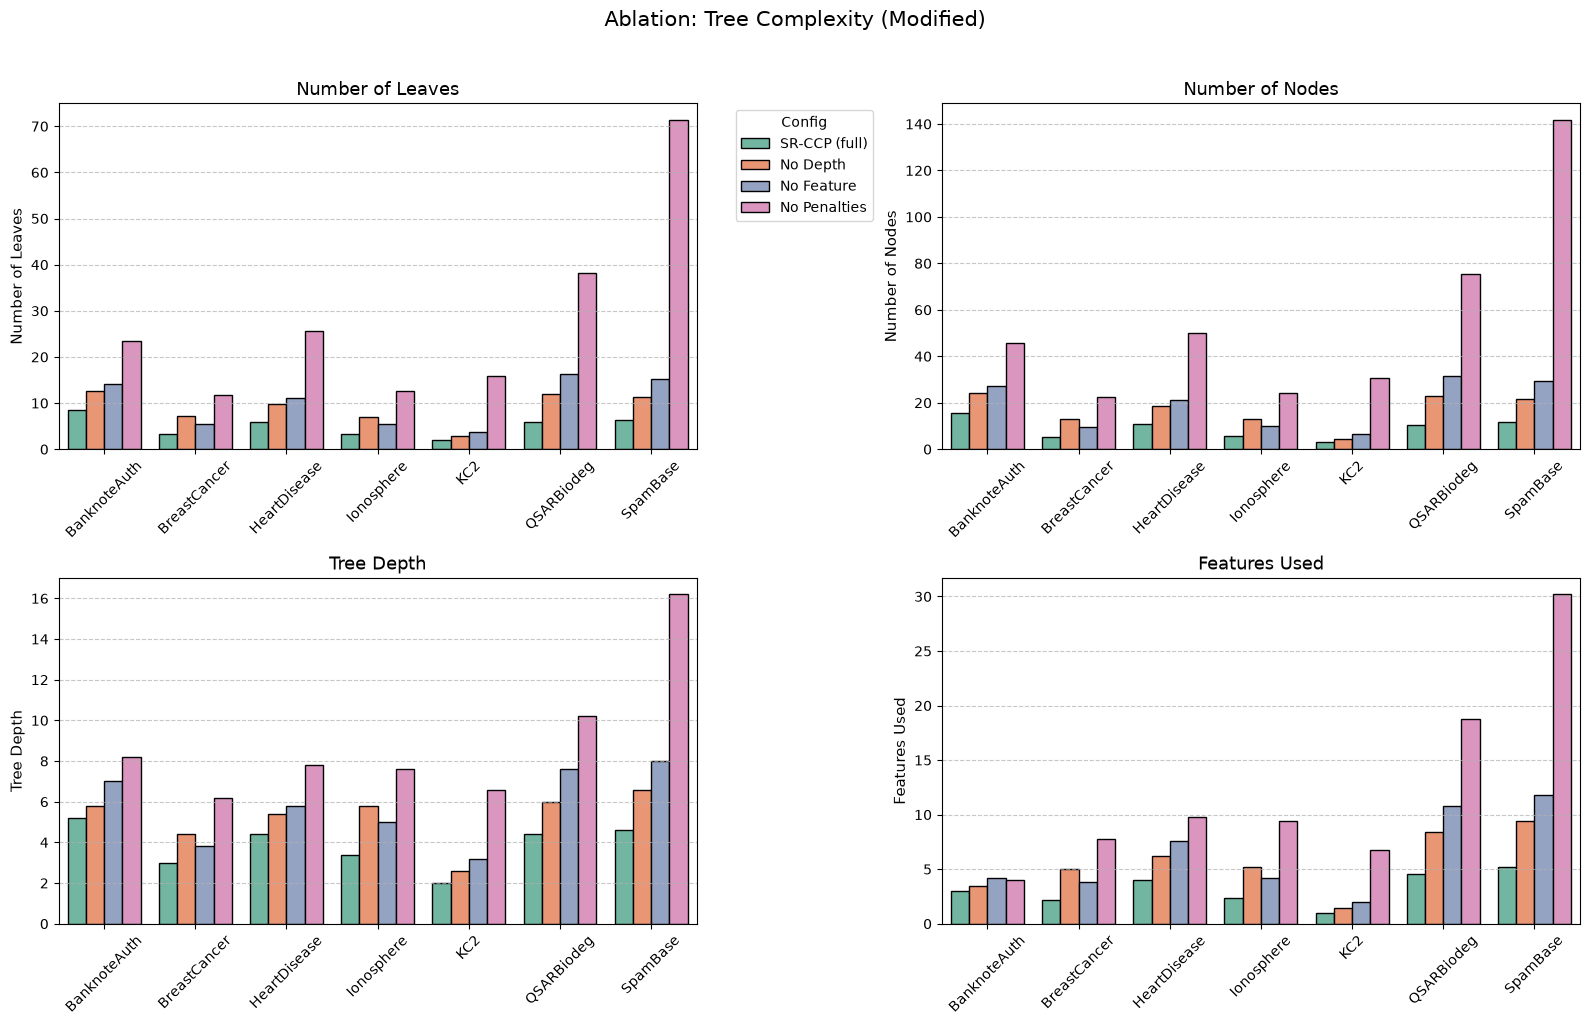

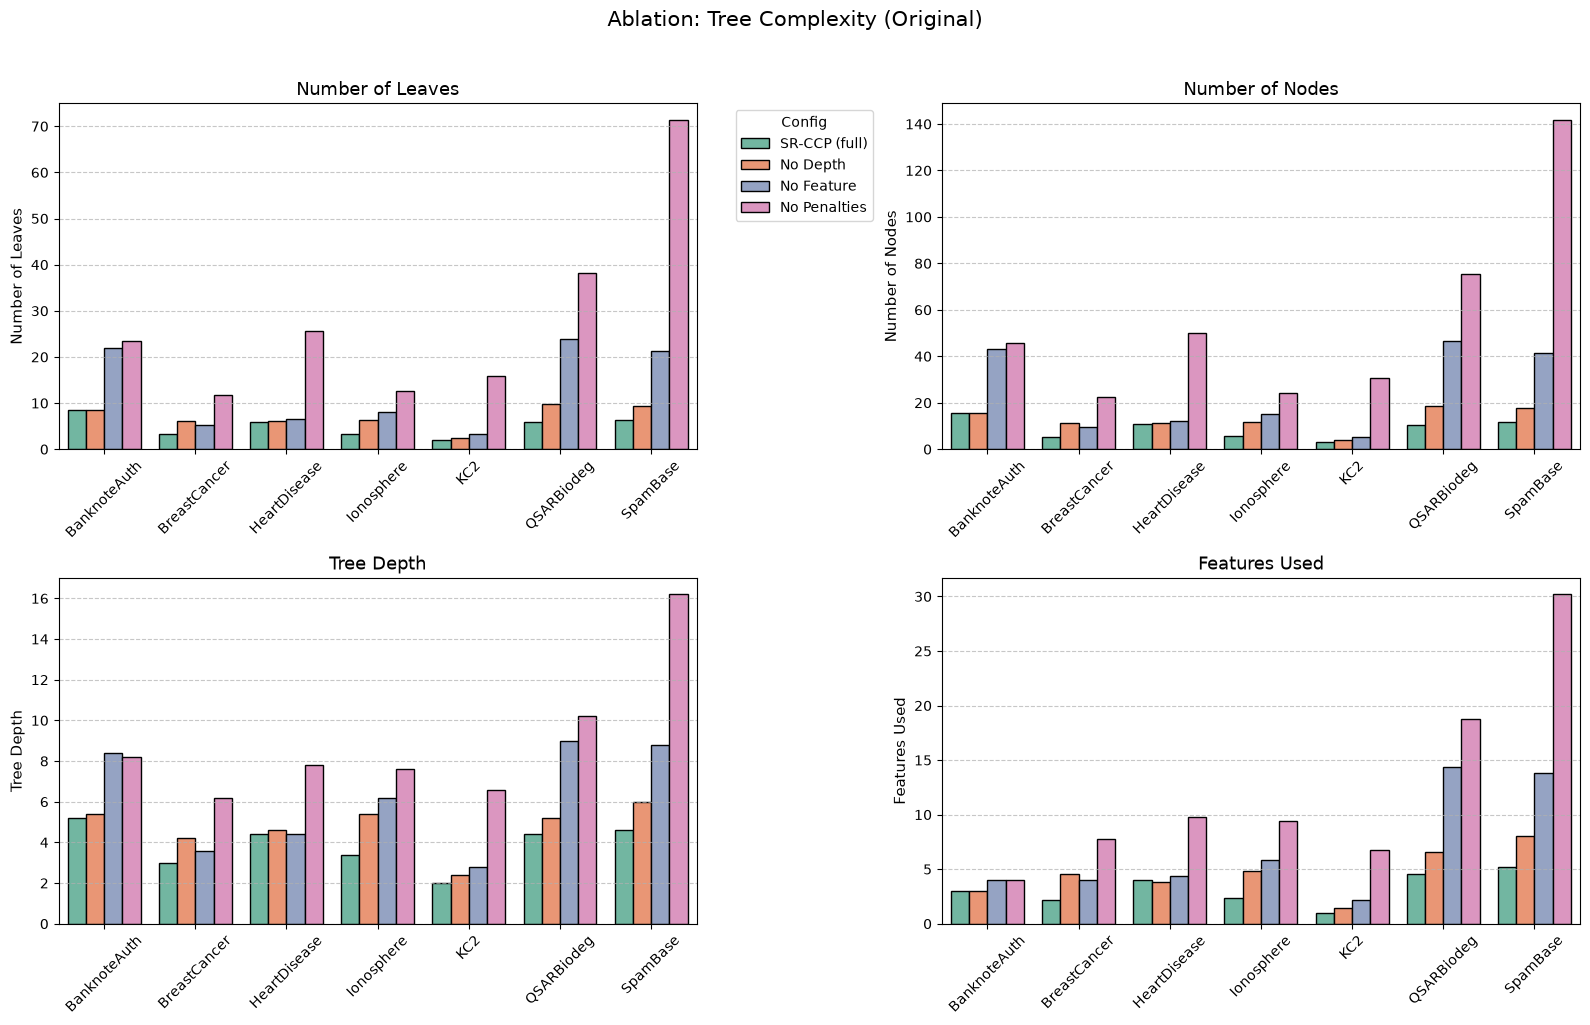

In [17]:
# --- Chart 2a: Tree complexity (Modified) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Ablation: Tree Complexity (Modified)', fontsize=15, y=1.02)
for ax, col, title in zip(axes.flat, ['Leaves', 'Nodes', 'Depth', 'n_Features'],
                         ['Number of Leaves', 'Number of Nodes', 'Tree Depth', 'Features Used']):
    sns.barplot(data=df, x='Dataset', y=col, hue='Config', palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax != axes[0, 0]:
        ax.get_legend().remove()
axes[0, 0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Chart 2b: Tree complexity (Original) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Ablation: Tree Complexity (Original)', fontsize=15, y=1.02)
for ax, col, title in zip(axes.flat, ['Leaves', 'Nodes', 'Depth', 'n_Features'],
                         ['Number of Leaves', 'Number of Nodes', 'Tree Depth', 'Features Used']):
    sns.barplot(data=df2, x='Dataset', y=col, hue='Config', palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax != axes[0, 0]:
        ax.get_legend().remove()
axes[0, 0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [18]:
# --- Delta from full SR-CCP (Modified) ---
full = df[df['Config'] == 'SR-CCP (full)'].set_index('Dataset')
print('DELTA vs SR-CCP (full) — Modified')
print('='*60)
for cfg in ['No Depth', 'No Feature', 'No Penalties']:
    partial = df[df['Config'] == cfg].set_index('Dataset')
    delta_acc = partial['Accuracy'] - full['Accuracy']
    delta_feat = partial['n_Features'] - full['n_Features']
    delta_leaves = partial['Leaves'] - full['Leaves']
    print(f"\n{cfg} vs SR-CCP:")
    print(f"  Mean ΔAccuracy: {delta_acc.mean():+.4f}")
    print(f"  Mean ΔFeatures: {delta_feat.mean():+.1f}")
    print(f"  Mean ΔLeaves:   {delta_leaves.mean():+.1f}")

# --- Delta from full SR-CCP (Original) ---
full2 = df2[df2['Config'] == 'SR-CCP (full)'].set_index('Dataset')
print('\n\nDELTA vs SR-CCP (full) — Original')
print('='*60)
for cfg in ['No Depth', 'No Feature', 'No Penalties']:
    partial2 = df2[df2['Config'] == cfg].set_index('Dataset')
    delta_acc2 = partial2['Accuracy'] - full2['Accuracy']
    delta_feat2 = partial2['n_Features'] - full2['n_Features']
    delta_leaves2 = partial2['Leaves'] - full2['Leaves']
    print(f"\n{cfg} vs SR-CCP:")
    print(f"  Mean ΔAccuracy: {delta_acc2.mean():+.4f}")
    print(f"  Mean ΔFeatures: {delta_feat2.mean():+.1f}")
    print(f"  Mean ΔLeaves:   {delta_leaves2.mean():+.1f}")


DELTA vs SR-CCP (full) — Modified

No Depth vs SR-CCP:
  Mean ΔAccuracy: -0.0187
  Mean ΔFeatures: +2.4
  Mean ΔLeaves:   +3.9

No Feature vs SR-CCP:
  Mean ΔAccuracy: -0.0153
  Mean ΔFeatures: +3.1
  Mean ΔLeaves:   +5.2

No Penalties vs SR-CCP:
  Mean ΔAccuracy: -0.0025
  Mean ΔFeatures: +9.2
  Mean ΔLeaves:   +23.4


DELTA vs SR-CCP (full) — Original

No Depth vs SR-CCP:
  Mean ΔAccuracy: -0.0243
  Mean ΔFeatures: +1.4
  Mean ΔLeaves:   +1.9

No Feature vs SR-CCP:
  Mean ΔAccuracy: -0.0159
  Mean ΔFeatures: +3.7
  Mean ΔLeaves:   +7.8

No Penalties vs SR-CCP:
  Mean ΔAccuracy: -0.0025
  Mean ΔFeatures: +9.2
  Mean ΔLeaves:   +23.4
